.<center> 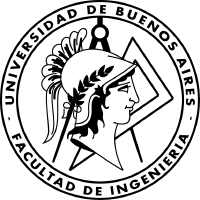



**Universidad de Buenos Aires**

**Facultad de Ingeniería**

**2do Cuatrimestre de 2025**

**Taller de Procesamiento de Señales**

---

**TP3: Regresión Logística**

**Alumno:** Lo Coco, Manuel - mlococo@fi.uba.ar - 103938 </center>

---


## (a) Exploración de Datos:


### (a.1)


Se cargan los datos de la base de datos MNIST, que posee imágenes de los dígitos manuscritos (del 0 al 9).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow

(x_train, y_train), (x_test, y_test) = tensorflow.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


### (a.2)


Se imprimen 10 imágenes aleatorias de la base de datos.

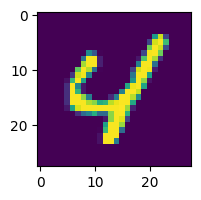

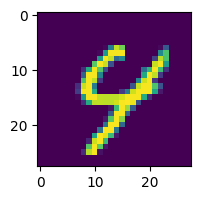

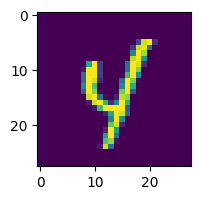

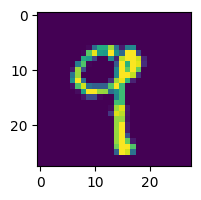

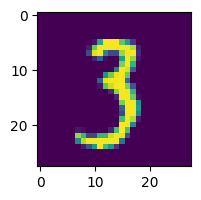

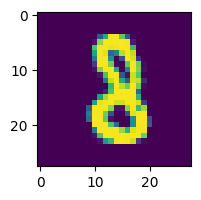

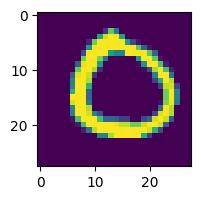

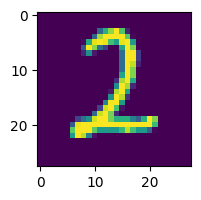

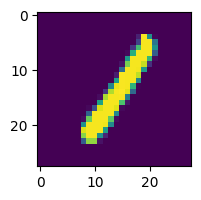

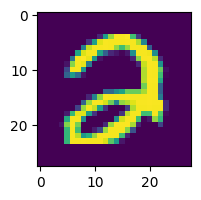

In [2]:
indices=np.random.randint(0,x_train.shape[0],10)
for i in indices:
  plt.figure(figsize=(2,2))
  plt.imshow(x_train[i])
  plt.show()

### (a.3)

En el trabajo se entrena un clasificador que predice si un dígito es par o impar, y por lo tanto, se dividen los datos en dos subconjuntos: uno de dígitos pares y otros de impares.

In [3]:
y_train_parity = y_train % 2
y_test_parity = y_test % 2
x_train = x_train.reshape(x_train.shape[0],-1)
x_test = x_test.reshape(x_test.shape[0],-1)

print(y_train[:20])
print(y_train_parity[:20])

[5 0 4 1 9 2 1 3 1 4 3 5 3 6 1 7 2 8 6 9]
[1 0 0 1 1 0 1 1 1 0 1 1 1 0 1 1 0 0 0 1]


## (b) Preprocesamiento

En la parte de preprocesamiento se realiza una normalización que se implementa con una clase. Con la normalización forzamos a la variable de entrada a tener media nula y varianza unitaria. La clase básicamente hace la siguiente transformación:
$$\frac{(x)_k-\mu_k}{\sigma_k}\rightarrow (x)_k$$

En donde la media se calcula como:
$$\mu_k=\frac{1}{n_{tr}}\sum_{i=1}^{n_{tr}}(x_i)_k$$

Por otra parte, el desvío estándar se calcula como:
$$\sigma_{k}=\sqrt{\frac{1}{n_{tr}}\sum_{i=1}^{n_{tr}}[(x_i)_k-\mu_k]^2}$$

### (b.1)


Para la normalización se descartan los features con varianza nula.

In [4]:
class Normalizar:
  def __init__(self, ):
    self.mu = None
    self.sigma = None
    self.valid_features = None

  # Etapa de entrenamiento
  def fit(self,X):
    mu_col = np.mean(X, axis=0)
    sigma_col = np.std(X, axis=0)
    self.valid_features = sigma_col > 1e-10
    self.mu = mu_col[self.valid_features]
    self.sigma = sigma_col[self.valid_features]

  # Aplicar la transformación
  def transform(self,X):
    x_valid = X[:,self.valid_features]
    return (x_valid - self.mu) / self.sigma

  # Entrenar y aplicar la transformación
  def fit_transform(self,X):
    self.fit(X)
    return self.transform(X)


### (b.2)

Se normalizan los conjuntos de entrenamiento y testeo, además, se verifica que una vez normalizados tengan media nula y varianza unitaria.

In [5]:
norm = Normalizar()
X_train_norm = norm.fit_transform(x_train)
X_test_norm = norm.transform(x_test)

print("Media de x_train: ", np.mean(x_train))
print("Media de x_train normalizada: ", np.mean(X_train_norm))
print("Varianza de x_train: ", np.std(x_train))
print("Varianza de x_train normalizada: ", np.std(X_train_norm))


print("\nMedia de x_test: ", np.mean(x_test))
print("Media de x_test normalizada: ", np.mean(X_test_norm))
print("Varianza de x_test: ", np.std(x_test))
print("Varianza de x_test normalizada: ", np.std(X_test_norm))

Media de x_train:  33.318421449829934
Media de x_train normalizada:  -5.395962616755572e-19
Varianza de x_train:  78.56748998339798
Varianza de x_train normalizada:  1.000000000000012

Media de x_test:  33.791224489795916
Media de x_test normalizada:  0.002722212957028458
Varianza de x_test:  79.17246322228644
Varianza de x_test normalizada:  1.0007860989165973


## (c) Análisis Teórico:

### (c.1)

La función sigmoide se define como:

$$\sigma(z)=\frac{1}{1+e^{-z}}$$

Si definimos $\sigma(z)=p$ se tiene que:

$$p=\frac{1}{1+e^{-z}}\Rightarrow pe^{-z}=1-p$$

Luego se continua con el despeje:

$$e^{-z}=\frac{1-p}{p}\Rightarrow -z=\ln\bigg(\frac{1-p}{p}\bigg)\Rightarrow z=\ln\bigg(\frac{p}{1-p}\bigg)$$

Finalmente se llega al resultado de la función inversa de la signmoide:

$$\boxed{\sigma^{-1}(p)=\ln\bigg(\frac{p}{1-p}\bigg)}$$

### (c.2)

La función sigmoide se define como:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Para calcular su derivada, aplicamos la regla de la cadena:

$$\bigg(f(g(z))\bigg)' = f'(g(z))\cdot g'(z)$$

Entonces, derivando:

$$\sigma'(z) = -\bigg(\frac{1}{1+e^{-z}}\bigg)^2\bigg(-e^{-z}\bigg) = \frac{e^{-z}}{(1+e^{-z})^2}$$

lo que es equivalente a:

$$\sigma'(z) = \frac{1}{1+e^{-z}} \cdot \frac{e^{-z}}{1+e^{-z}}$$

El primer factor es $\sigma(z)$ y el segundo se puede expresar como $1 - \sigma(z)$. De este modo se obtiene:

$$\sigma'(z) = \sigma(z)\,\big(1-\sigma(z)\big)$$

Finalmente, si llamamos $p = \sigma(z)$, se llega a la forma más simple:

$$\boxed{\sigma'(z) = p(1-p)}$$


### (c.3)

La regresión logística utiliza como función de costo la *log-loss* (también llamada entropía cruzada binaria), definida como:

$$l(x,y) = - \log \hat{P}(Y|X)$$

En términos de la probabilidad estimada por el modelo, se puede expresar como:


$$l(x,y) =
\begin{cases}
- \log(\sigma(w^Tx+b)) & \text{si } y=1 \\
- \log(1-\sigma(w^Tx +b)) & \text{si } y=0
\end{cases}$$


De forma más compacta, la función de costo puede escribirse como:

$$l(x,y) = -y\log(\sigma(w^Tx+b))-(1-y)\log(1-\sigma(w^Tx+b))$$

Para calcular el gradiente se divide a la función *log-loss* con respecto a $b$ y $w$:


$$\frac{\partial l(x,y)}{\partial w} =\frac{y\cdot x \cdot\sigma(z)(1-\sigma(z))}{\sigma(z)}
+\frac{(1-y) \cdot (-\sigma(z))(1-\sigma(z)) \cdot x}{1-\sigma(z)}$$


Aplicando distrbibutivas se llega a que:

$$
\frac{\partial l(x,y)}{\partial w}= -y \cdot x + y \cdot x \cdot \sigma(z) + (1-y)x \cdot \sigma(z)
$$

Finalmente:

$$\boxed{\frac{\partial l(x,y)}{\partial w}= x(\sigma(z) - y)}$$

En el caso de la derivada con respecto a b se tiene que:

$$\frac{\partial l(x,y)}{\partial b} =\frac{y\cdot \sigma(z)(1-\sigma(z))}{\sigma(z)}+\frac{(1-y)(-\sigma(z))(1-\sigma(z))}{1-\sigma(z)}$$

Aplicando distributivas se llega a que:

$$\frac{\partial l(x,y)}{\partial b}=-y + y \cdot \sigma(z) + (1-y)\sigma(z)$$

Finalmente:
$$\boxed{\frac{\partial l(x,y)}{\partial b}= \sigma(z)-y}$$



## (d) Regresión Logística

### (d.1)

Se implementa una regresión logística binaria utilizando gradiente descendente. El método del gradiente descendente tiene como solución para este caso la siguiente ecuación:
$$\textbf{w}_{t+1}=\textbf{w}_t-\alpha\nabla J(\textbf{w}_t)$$

El riesgo empírico $J(w,b)$ se calcula en este caso como:

$$J(w,b)=\frac{1}{n_{tr}}\sum_{i=1}^{n_{tr}}l(x_i,y_i)$$

donde $l(x,y)$ es la función *log-loss* ya desarrollada en el punto anterior y por ende se concluye que:

$$\frac{\partial J(w,b)}{\partial w}=\frac{1}{n_{tr}}\sum_{i=1}^{n_{tr}}x_i[\sigma(w^Tx_i+b)-y_i]\\
\frac{\partial J(w,b)}{\partial b}=\frac{1}{n_{tr}}\sum_{i=1}^{n_{tr}}[\sigma(w^Tx_i+b)-y_i]$$

In [6]:
class RegresionLogistica:
  def __init__(self, n, learning_rate):
    self.w = None
    self.b = None
    self.lr = learning_rate
    self.n_iter = n
    self.J = []

  def sigmoide(self, z):
    return 1/(1+np.exp(-z))

  # Etapa de entrenamiento
  def fit(self,X,y):
    y = y.reshape(-1,1)
    self.w = np.zeros((X.shape[1],1))
    self.b = 0

    for i in range(self.n_iter):
      z = np.dot(X, self.w) + self.b
      y_hat = self.sigmoide(z)

      # Se calculan los gradientes de J con respecto a w y b
      dw = (1 / X.shape[0]) * np.dot(X.T, (y_hat - y))
      db = (1/ X.shape[0]) * np.sum(y_hat - y)

      # Se utiliza la ecuación de gradiente descendente
      self.w = self.w - self.lr * dw
      self.b = self.b - self.lr * db

      # Se calcula el costo para cada iteración
      loss = -np.mean(y * np.log(y_hat) + (1-y) * np.log(1-y_hat))
      self.J.append(loss)

  # Etapa de testeo soft
  def predict_proba(self,X):
    return self.sigmoide(np.dot(X, self.w)+self.b)

  # Etapa de testeo hard
  def predict(self,X):
    y_prob = self.predict_proba(X)
    return np.round(y_prob)

  # Computar el Accuracy
  def accuracy(self,X,y):
    y = y.reshape(-1,1)
    y_pred = self.predict(X)
    acc = np.mean(y_pred == y)
    return acc

  # Computar la Cross-Entropy
  def cross_entropy(self,X,y):
    y = y.reshape(-1,1)
    y_hat = self.predict_proba(X)
    return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

### (d.2)

El algoritmo se entrenó probando distintos valores de learning rate y diferentes cantidades de iteraciones, hasta observar curvas en las que el riesgo empírico de entrenamiento convergía rápidamente. Finalmente, se eligieron un learning rate de 0.5 y 50 iteraciones como parámetros óptimos.

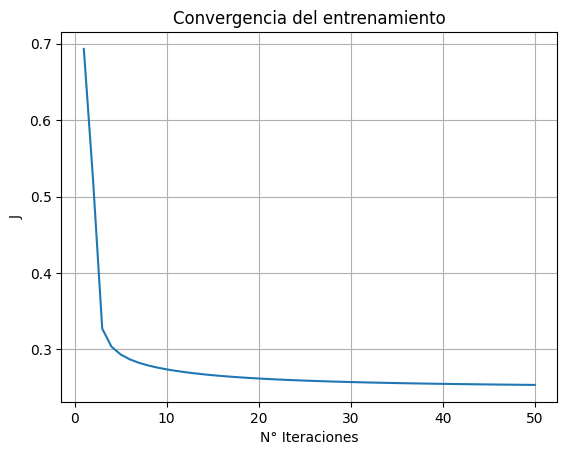

In [7]:
n_iter = 50
learning_rate = 0.5

rl = RegresionLogistica(n_iter, learning_rate)
rl.fit(X_train_norm, y_train_parity)
plt.plot(range(1, rl.n_iter+1), rl.J)
plt.xlabel("N° Iteraciones")
plt.ylabel("J")
plt.title("Convergencia del entrenamiento")
plt.grid(True)
plt.show()



### (d.3)

El accuracy o probabilidad de acierto se calcula como:

$$\text{Accuracy}=\mathbb{P}(Y=\varphi(X))\approx\frac{\#(Y=\varphi(X))}{n}$$

La cross-entropy se calcula como:

$$\text{cross-entropy}=\mathbb{E}[-\log \hat{P}(Y|X)]$$

y como en nuestro caso se tiene que $l(x,y)=-\log\hat{P}(Y|X)$, entonces la cross-entropy se calcula como:

$$\mathbb{E}[-y\log(\sigma(w^Tx+b))-(1-y)\log(1-\sigma(w^Tx+b))]$$

que se puede simplificar llamando $\hat{y}=\sigma(w^Tx+b)$:

$$\text{cross-entropy}=\mathbb{E}[-y\log\hat{y}-(1-y)\log(1-\hat{y})]$$

In [8]:
print("El accuracy de entrenamiento es: ", rl.accuracy(X_train_norm, y_train_parity))
print("El accuracy de testeo es: ", rl.accuracy(X_test_norm, y_test_parity))
print("La cross-entropy de entrenamiento es: ", rl.cross_entropy(X_train_norm, y_train_parity))
print("La cross-entropy de testeo es: ", rl.cross_entropy(X_test_norm, y_test_parity))

El accuracy de entrenamiento es:  0.9002333333333333
El accuracy de testeo es:  0.9005
La cross-entropy de entrenamiento es:  0.25339671005293457
La cross-entropy de testeo es:  0.2570284360226865


## (e) Curva ROC

Para evaluar el desempeño se utiliza la curva ROC (Receiver Operating Characteristic). Esta curva representa la relación entre la tasa de verdaderos positivos (TPR) y la tasa de falsos positivos (FPR) para distintos umbrales de decisión.
Para calcular la curva ROC, se calculan en primer lugar los valores de TP, FN, FP y TN en función de $y$ e $\hat{y}$:

|| TP (True Positive) | FN (False Negative) | FP (False positive) |TN (True Negative)|
|----|--------------------|--------------------|--------------------|--------------------|
|$y$|1|1| 0|0|
|$\hat{y}$|1|0|1|0|


Luego, se definen el FPR y el TPR se definen como:

$$FPR=\mathbb{P}(Y\neq\varphi(X)|Y=0)=\frac{FP}{FP+TN}$$

$$TPR=\mathbb{P}(Y=\varphi(X)|Y=1)=\frac{TP}{TP+FN}$$

In [9]:
def ROC(y, y_prob, steps):
  y = y.reshape(-1,1)
  y_prob = y_prob.reshape(-1,1)
  TPR_list = []
  FPR_list = []
  threshold = np.linspace(0,1,steps)
  for thr in threshold:
    y_pred = (y_prob >= thr).astype(int)
    TP = np.sum((y == 1) & (y_pred == 1))
    FN = np.sum((y == 1) & (y_pred == 0))
    FP = np.sum((y == 0) & (y_pred == 1))
    TN = np.sum((y == 0) & (y_pred == 0))

    FPR = FP / (FP + TN)
    TPR = TP / (TP + FN)

    TPR_list.append(TPR)
    FPR_list.append(FPR)

  return np.array(TPR_list), np.array(FPR_list)

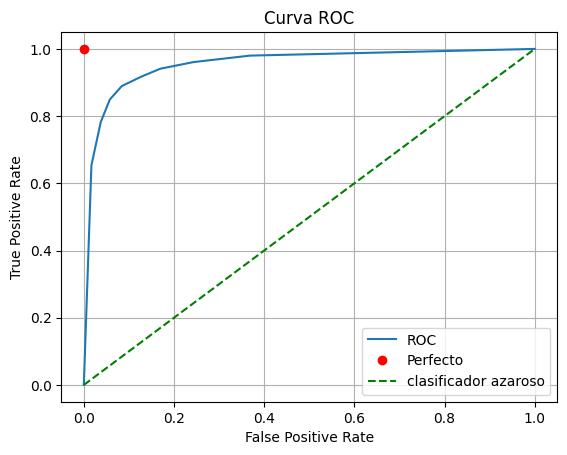

In [10]:
TPR, FPR = ROC(y_test_parity, rl.predict_proba(X_test_norm), 10)

plt.plot(FPR, TPR, label="ROC")
plt.plot(0, 1,  'ro', label = "Perfecto")
plt.plot([0,1], [0,1], "--", color="green", label='clasificador azaroso')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.grid()
plt.legend()
plt.show()

En la curva ROC se puede observar que se logró un buen desempeño del clasificador, ya que la curva se encuentra del punto superior izquierdo que significa un TPR alto y un FPR bajo. También se puede apreciar que el AUC (área bajo la curva) es cercano a 1 lo que confirma el buen desempeño del clasificador.

## Conclusiones

Se desarrolló la regresión logística desde cero, incluyendo la función sigmoide, la función de costo con entropía cruzada y su gradiente, entrenando el modelo mediante gradiente descendente hasta la convergencia del riesgo empírico.

El modelo logró predecir correctamente los dígitos del conjunto de testeo, con métricas de accuracy satisfactorias, y las curvas de riesgo y probabilidad permitieron evaluar su desempeño y ajustar hiperparámetros. Este ejercicio evidencia la importancia del preprocesamiento, la implementación analítica de la función de pérdida y la visualización de resultados para interpretar y optimizar un modelo de clasificación binaria.